# Incorporating prior knowledge in a multi-omic multi-group setting

In this notebook, we apply MOFA-FLEX to a published {cite:p}`pmid33589839` multi-omic CITE-seq dataset profiling murine spleen and lymph node cells, which includes both transcriptome (RNA) and surface protein measurements collected across independent batches.
The goal is to integrate these complementary modalities while disentangling unwanted technical variation (batch effects) from true biological signal, such as immune cell-type–specific programs.

We configure MOFA-FLEX with:
- a multi-view architecture linking RNA and protein modalities,
- domain knowledge priors derived from Hallmark and Microwell-seq gene programs to guide biologically meaningful latent factors,
- non-negativity constraints to enhance interpretability, and
- a small number of uninformed factors to absorb residual variation, including batch-specific effects.

This example demonstrates how MOFA-FLEX can isolate biological structure from confounding noise in complex multi-omic datasets.

In [1]:
import anndata as ad
import fsspec
import mofaflex as mfl
import mudata as md
import numpy as np
import pandas as pd
import scanpy as sc
from plotnine import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Loading and preprocessing the data

We begin by loading the CITE-seq dataset comprising matched RNA and surface protein modalities from murine spleen and lymph node cells.
The raw AnnData object is preprocessed to remove doublets and low-quality cells, retaining biologically relevant immune cell types such as B cells, T cells, NK cells, macrophages, and dendritic cells.
- cell-type harmonisation: fine-grained annotations (e.g., MZ B, Transitional B) are collapsed into broad immune cell categories for consistent downstream analysis,
- view creation: the dataset is split into two modalities, a gene expression view (rna) and a surface protein view (prot), and combined into a multi-view `MuData` object,
- normalisation: each modality is log-transformed and scaled to unit variance to ensure comparability across data types.

The resulting `MuData` object forms the input for MOFA-FLEX, which treats each modality as a complementary "view" of the same set of cells.

In [2]:
# remove doublets and low quality cells
relevant_cell_types = [
    "Activated CD4 T",
    # 'B doublets',
    # 'B-CD4 T cell doublets',
    # 'B-CD8 T cell doublets',
    # 'B-macrophage doublets',
    "B1 B",
    "CD122+ CD8 T",
    "CD4 T",
    "CD8 T",
    # 'Cycling B/T cells',
    "Erythrocytes",
    "GD T",
    "ICOS-high Tregs",
    "Ifit3-high B",
    "Ifit3-high CD4 T",
    "Ifit3-high CD8 T",
    # 'Low quality B cells',
    # 'Low quality T cells',
    "Ly6-high mono",
    "Ly6-low mono",
    "MZ B",
    "MZ/Marco-high macrophages",
    "Mature B",
    "Migratory DCs",
    "NK",
    "NKT",
    "Neutrophils",
    "Plasma B",
    "Red-pulp macrophages",
    # 'T doublets',
    "Transitional B",
    "Tregs",
    "cDC1s",
    "cDC2s",
    "pDCs",
]

cell_type_map = {
    "Mature B": "B",
    "Transitional B": "B",
    "Ifit3-high B": "B",
    "MZ B": "B",
    "B1 B": "B",
    "Plasma B": "B",
    "CD4 T": "CD4",
    "Ifit3-high CD4 T": "CD4",
    "Activated CD4 T": "CD4",
    "CD8 T": "CD8",
    "CD122+ CD8 T": "CD8",
    "Ifit3-high CD8 T": "CD8",
    "Tregs": "Tregs",
    "ICOS-high Tregs": "Tregs",
    # 'GD T': 'GD T',
    "NKT": "NK",
    "NK": "NK",
    "Neutrophils": "Neutrophils",
    "Ly6-high mono": "Ly6",
    "Ly6-low mono": "Ly6",
    "cDC2s": "DC",
    "cDC1s": "DC",
    "Migratory DCs": "DC",
    "pDCs": "DC",
    "Erythrocytes": "Erythrocytes",
    "MZ/Marco-high macrophages": "Macrophages",
    "Red-pulp macrophages": "Macrophages",
}

with fsspec.open(
    "https://github.com/YosefLab/scVI-data/raw/master/sln_208.h5ad",
    client_kwargs={"trust_env": True},
) as f:
    adata_rna = ad.read_h5ad(f)
adata_rna.var_names_make_unique()
adata_rna.X = np.array(adata_rna.X.todense(), dtype=np.float32)

adata_rna.obs_names = adata_rna.obs_names.str.upper()
adata_rna.var_names = adata_rna.var_names.str.upper()

adata_rna._inplace_subset_var(adata_rna.var["highly_variable"])

adata_rna._inplace_subset_obs(adata_rna.obs["cell_types"].isin(relevant_cell_types))
adata_rna.obs["cell_types"] = adata_rna.obs["cell_types"].cat.remove_unused_categories()

adata_rna.obs["cell_types (high)"] = (
    adata_rna.obs["cell_types"].map(cell_type_map).astype("category")
)

df_prot = pd.DataFrame(
    adata_rna.obsm["protein_expression"],
    index=adata_rna.obs_names,
    columns=pd.Index(adata_rna.uns["protein_names"]).str.upper(),
    dtype=np.float32,
)
df_prot = df_prot.dropna(axis=1, how="all")
adata_prot = ad.AnnData(df_prot)
mdata = md.MuData(
    {
        "rna": adata_rna,
        "prot": adata_prot,
    }
)

for adata in mdata.mod.values():
    adata.X = np.log1p(adata.X)
    adata.X = adata.X - np.nanmin(adata.X, axis=0)
    global_std = np.nanstd(adata.X)
    adata.X /= global_std

mdata

/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1581: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1457: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 14870 × 4112
  2 modalities
    rna:	14870 x 4000
      obs:	'n_proteins', 'batch_indices', 'n_genes', 'percent_mito', 'leiden_subclusters', 'cell_types', 'tissue', 'batch', 'cell_types (high)'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'encode', 'hvg_encode'
      uns:	'protein_names', 'version'
      obsm:	'isotypes_htos', 'protein_expression'
    prot:	14870 x 112

## Loading and filtering gene set annotations (gene programs)

To guide the inference of biologically meaningful factors, we incorporate prior knowledge in the form of curated gene programs.
For this experiment, we use:
- Hallmark gene sets from the MSigDB mouse collection (v2023.2), capturing well-defined biological processes such as interferon response, apoptosis, and oxidative phosphorylation,
- Microwell-seq (MCA) cell type signatures, providing expression profiles of major immune cell types from large-scale single-cell atlases.
  The cell type signatures were extracted from the spleen tissue in Table S5 of {cite:t}`pmid29775597`.

These resources are combined into a unified FeatureSets object and filtered to match the genes present in the CITE-seq dataset, removing sets that are too small or too broad.
We also merge highly similar gene programs using Jaccard similarity to reduce redundancy.

The resulting collection provides the domain knowledge prior that will inform the RNA modality during model training, enabling interpretable, biologically grounded latent factors.

In [3]:
def to_upper(feature_set_collection):
    return mfl.FeatureSets(
        [
            mfl.FeatureSet([f.upper() for f in fs], fs.name)
            for fs in feature_set_collection
        ],
        name=feature_set_collection.name,
    )

In [4]:
hallmark_collection = to_upper(
    mfl.tl.msigdb_get_features(category="mh.all", dbver="2023.2.Mm")
).filter(
    mdata["rna"].var_names,
    min_fraction=0.1,
    min_count=15,
    max_count=300,
)
with fsspec.open(
    "https://github.com/bioFAM/mofaflex-analysis/raw/refs/heads/main/msigdb/mmc5_gene.gmt",
    mode="rt",
    client_kwargs={"trust_env": True},
) as f:
    mca_collection = to_upper(mfl.FeatureSets.from_gmt(f, name="mca")).filter(
        mdata["rna"].var_names,
        min_fraction=0.1,
        min_count=15,
        max_count=300,
    )
gene_set_collection = hallmark_collection | mca_collection
gene_set_collection = gene_set_collection.merge_similar(
    metric="jaccard",
    similarity_threshold=0.8,
    iteratively=True,
)
gene_set_collection

INFO	Found 0 pairs to merge. Stopping...


<FeatureSets 'mh.all.v2023.2.Mm.symbols|mca' with 56 feature sets>

## Prettifying gene program names for better plotting

For clarity in downstream plots, we standardise and shorten gene program names.
This helper function removes technical prefixes (e.g. `HALLMARK_`, `REACTOME_`), replaces underscores with spaces, abbreviates overly long names, and tags each entry with its database source (`[H]` for Hallmark, `[R]` for Reactome).
These formatted labels improve readability in UMAPs, heatmaps, and variance explained plots.

In [5]:
import re


def _prettify_name(
    name: str,
    mapper: dict[str, str] = None,
    abbreviation_length: int = 40,
    end_with_database: bool = True,
) -> str:
    if not isinstance(name, str):
        raise TypeError("`factor` must be a string.")
    if not isinstance(abbreviation_length, int) or abbreviation_length <= 0:
        raise ValueError("`abbreviation_length` must be a positive integer.")

    # Replace underscores with spaces
    name = name.replace("_", " ")

    # Replace using dictionary
    if mapper is not None:
        for key, value in mapper.items():
            name = name.replace(key, value)

    # Abbreviate if needed
    if len(name) > abbreviation_length:
        name = name[:abbreviation_length] + "…"

    # Move [X] from beginning to end, e.g. "[DB] Name" → "Name [DB]"
    if end_with_database:
        match = re.match(r"^(\[.*\]) (.*)", name)
        if match:
            name = f"{match.group(2)} {match.group(1)}"

    # Title case
    return name.title()


for gs in gene_set_collection:
    gs.name = _prettify_name(gs.name, mapper={"HALLMARK": "[H]", "HAN": "[M]"})

sorted([(len(gs), gs.name) for gs in gene_set_collection])[:10]

[(15, 'Notch Signaling [H]'),
 (21, 'Angiogenesis [H]'),
 (21, 'Tgf Beta Signaling [H]'),
 (24, 'Bile Acid Metabolism [H]'),
 (24, 'Protein Secretion [H]'),
 (28, 'Spermatogenesis [H]'),
 (29, 'Peroxisome [H]'),
 (29, 'Reactive Oxigen Species Pathway [H]'),
 (32, 'Kras Signaling Dn [H]'),
 (34, 'Myc Targets V2 [H]')]

## Storing gene program annotations as binary mask to AnnData

We next encode the filtered gene programs as a binary annotation matrix within the RNA modality of the MuData object.
Each gene program is represented as a binary mask indicating gene membership, stored in `varm["gene_set_mask"]`.

This matrix serves as input to the domain-knowledge module of MOFA-FLEX, enabling the model to associate latent factors with specific biological programs during training.

In [6]:
mdata["rna"].varm["gene_set_mask"] = gene_set_collection.to_mask(
    mdata["rna"].var_names.tolist()
).T

## Configuring and training a MOFA-FLEX model

We now configure and train MOFA-FLEX for multi-omic integration of the RNA and protein modalities.
Key configuration components include:
- `n_factors=3` specifies three uninformed latent factors.
  The uninformed factors will capture information that cannot be represented using our gene program collection.
  The total number of factors in the model will thus be 59: 56 gene programs plus three uninformed factors.
- A Horseshoe prior promotes sparsity while allowing flexible sharing of signal across modalities.
  The `gene_set_mask` annotation is linked to the RNA view to guide factor learning using biological priors.
- Both weights and factors are constrained to be non-negative for improved interpretability.
- Gaussian (Normal) likelihoods are chosen for both modalities, reflecting continuous, normalised data.
- The RNA and protein modalities are treated as views of a single group (i.e. same cells).

This configuration allows MOFA-FLEX to disentangle shared and modality-specific sources of variation, separating biological signal (e.g. cell-type programs) from technical or experimental noise.

In [7]:
model = mfl.terms.MofaFlex(
    n_factors=3,
    weight_prior=mfl.priors.InformedHorseshoe(annotations_mkey="gene_set_mask"),
    nonnegative_factors=True,
    nonnegative_weights=True,
    init_factors=0,
)
model.fit(
    mdata,
    likelihoods=mfl.likelihoods.Normal(scale_per_group=False),
    plot_data_overview=False,
    lr=0.003,
    seed=42,
    save_path=False,
)

/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1581: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1457: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1581: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new beha

  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 2
INFO	Training converged after 4605 epochs.
/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1581: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:1457: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


## Downstream analysis: Variance explained across modalities

After training, we assess how much variance each latent factor explains in the RNA and protein modalities.
The variance explained (R²) plot quantifies the contribution of each factor to each view, allowing us to distinguish:
- shared factors that capture coordinated RNA–protein variation, likely reflecting underlying biological programs (e.g. cell-type or pathway-level structure),
- modality-specific factors that may correspond to technical effects or unique variation within a single omic layer.

By visualizing the fraction of variance explained, we can identify the dominant factors and ensure that both data modalities are well represented by the learned latent structure.

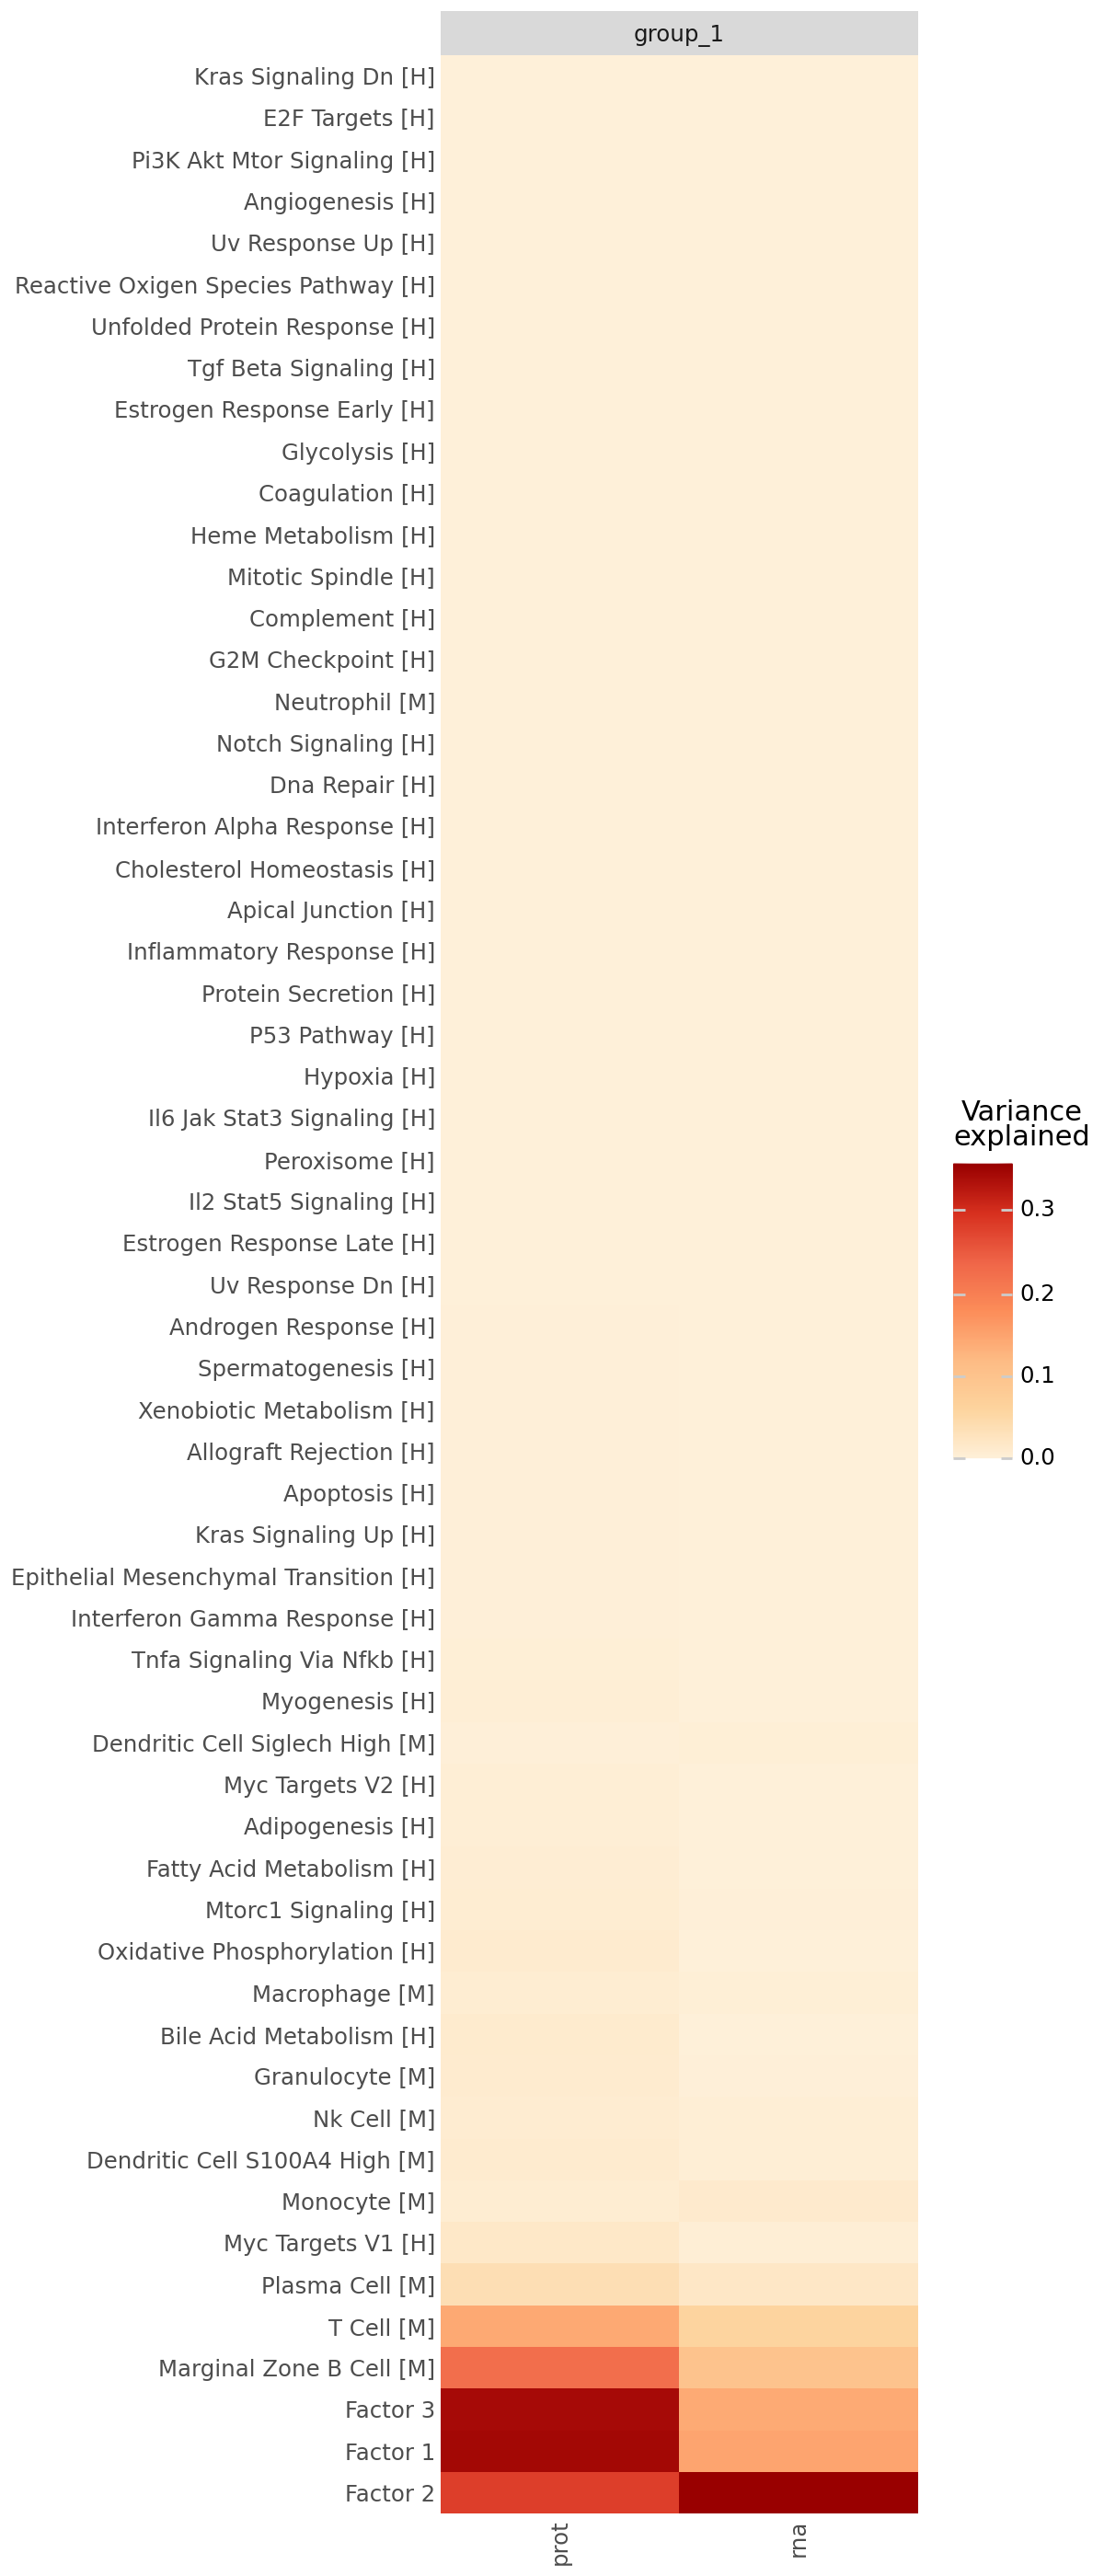

In [8]:
mfl.pl.variance_explained(model, figsize=(6, 14))

## Filtering and organizing informative latent factors

We next extract the subset of informative latent factors that together explain most of the total variance.
The helper function `filter_factors()` selects factors whose cumulative variance contribution falls below a chosen threshold (`r2_thresh`, here set to 0.99).
This step removes factors that capture only minimal variation, simplifying interpretation without losing relevant signal.

The resulting AnnData object (`factor_adata`) contains the retained factors and associated cell metadata, with cell types harmonised into higher-level categories (e.g. B, CD4, Macrophages, etc.).

In [9]:
def filter_factors(model, r2_thresh=0.99):
    r2_df = model.get_r2()
    r2_sorted = r2_df.groupby("component")["R2"].sum().sort_values(ascending=False)

    if r2_thresh < 1.0:
        r2_thresh = (r2_sorted.cumsum() / r2_sorted.sum() < r2_thresh).sum() + 1

    return r2_sorted.iloc[: int(r2_thresh)].index


factor_adata = ad.AnnData(model.get_factors()["group_1"].loc[:, filter_factors(model)])
factor_adata.obs = mdata["rna"].obs
factor_adata = factor_adata[~factor_adata.obs["cell_types (high)"].isna(), :]
factor_adata.obs["cell_types (high)"] = pd.Categorical(
    factor_adata.obs["cell_types (high)"],
    categories=[
        "B",
        "CD4",
        "CD8",
        "DC",
        "NK",
        "Erythrocytes",
        "Ly6",
        "Macrophages",
        "Neutrophils",
        "Tregs",
    ],
)
factor_adata

/tmp/ipykernel_2197887/1770214141.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


AnnData object with n_obs × n_vars = 14738 × 20
    obs: 'n_proteins', 'batch_indices', 'n_genes', 'percent_mito', 'leiden_subclusters', 'cell_types', 'tissue', 'batch', 'cell_types (high)'

## Visualizing latent structure in a UMAP

To inspect the global organisation of the learned latent space, we project the factor scores (including both informed and uninformed factors) into two dimensions using UMAP.
This provides an intuitive overview of how samples cluster based on their shared molecular profiles.

In this plot cells are colored by batch, revealing the presence of residual batch-specific structure in the latent representation.
Such patterns indicate that while the model captures strong biological signal, technical variation between batches is still present.

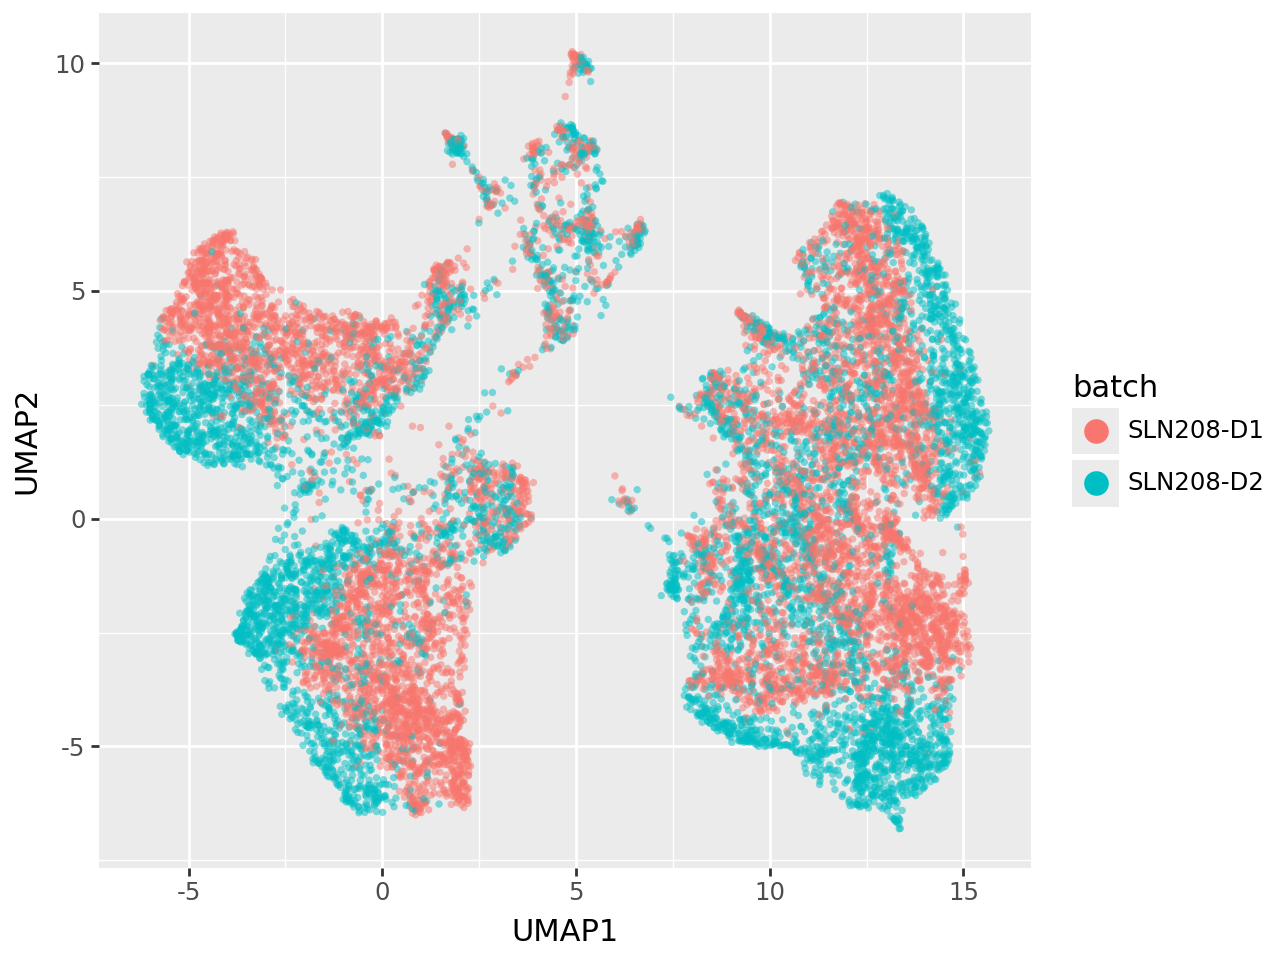

In [10]:
sc.pp.neighbors(factor_adata, use_rep="X")
sc.tl.umap(factor_adata, min_dist=0.4)
umap_data = pd.DataFrame(
    factor_adata.obsm["X_umap"],
    index=factor_adata.obs_names,
    columns=["UMAP1", "UMAP2"],
).assign(batch=factor_adata.obs["batch"])
umap_data = umap_data.sample(frac=1, replace=False)

(
    ggplot(umap_data, aes(x="UMAP1", y="UMAP2", fill="batch"))
    + geom_point(
        stroke=0,
        alpha=0.5,
    )
    + guides(fill=guide_legend(override_aes={"size": 5, "alpha": 1}))
)

We now visualize the uninformed factors in pairwise scatterplots.
This shows that all three uninformed factors capture technical (batch) variation to varying extents.

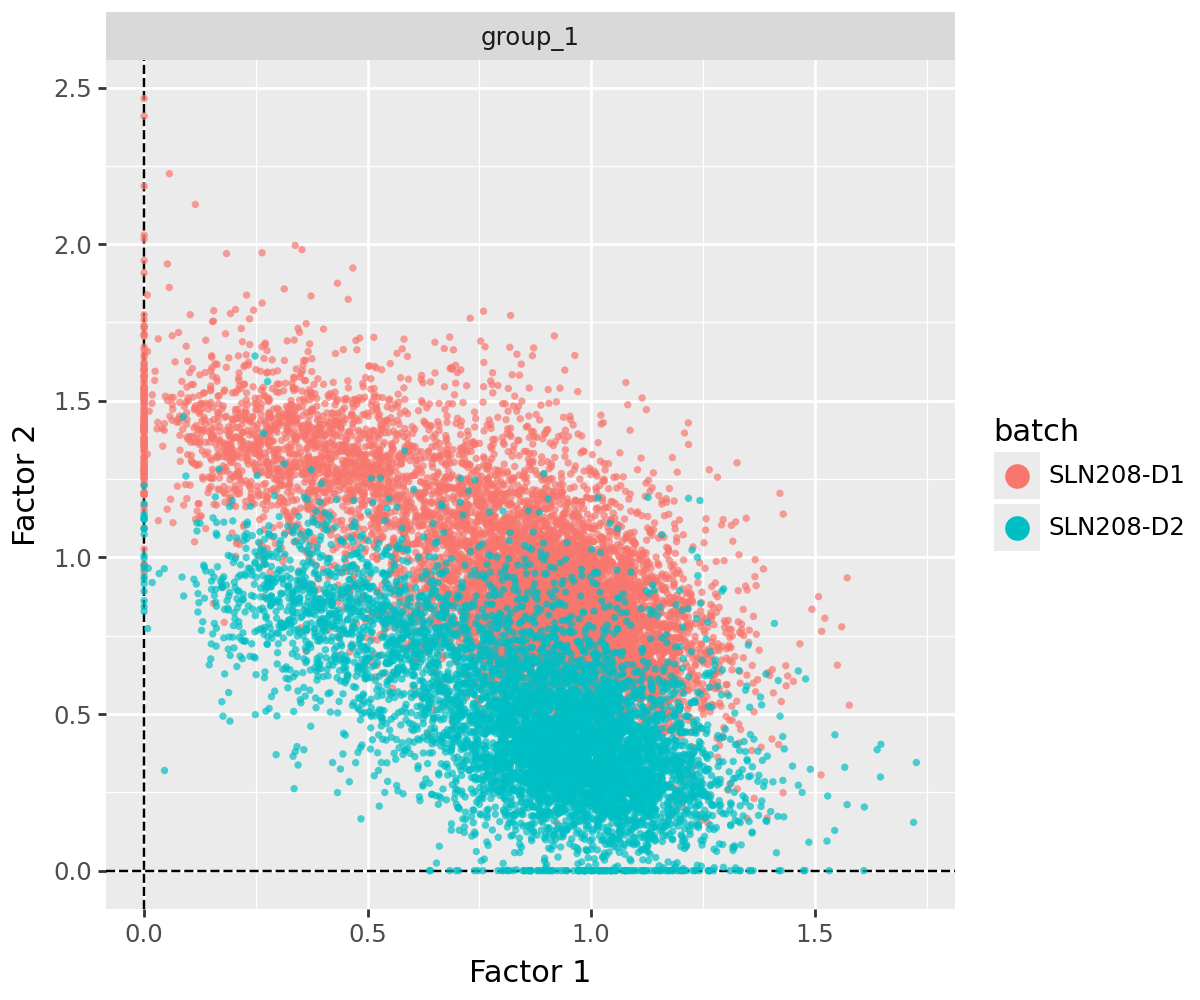

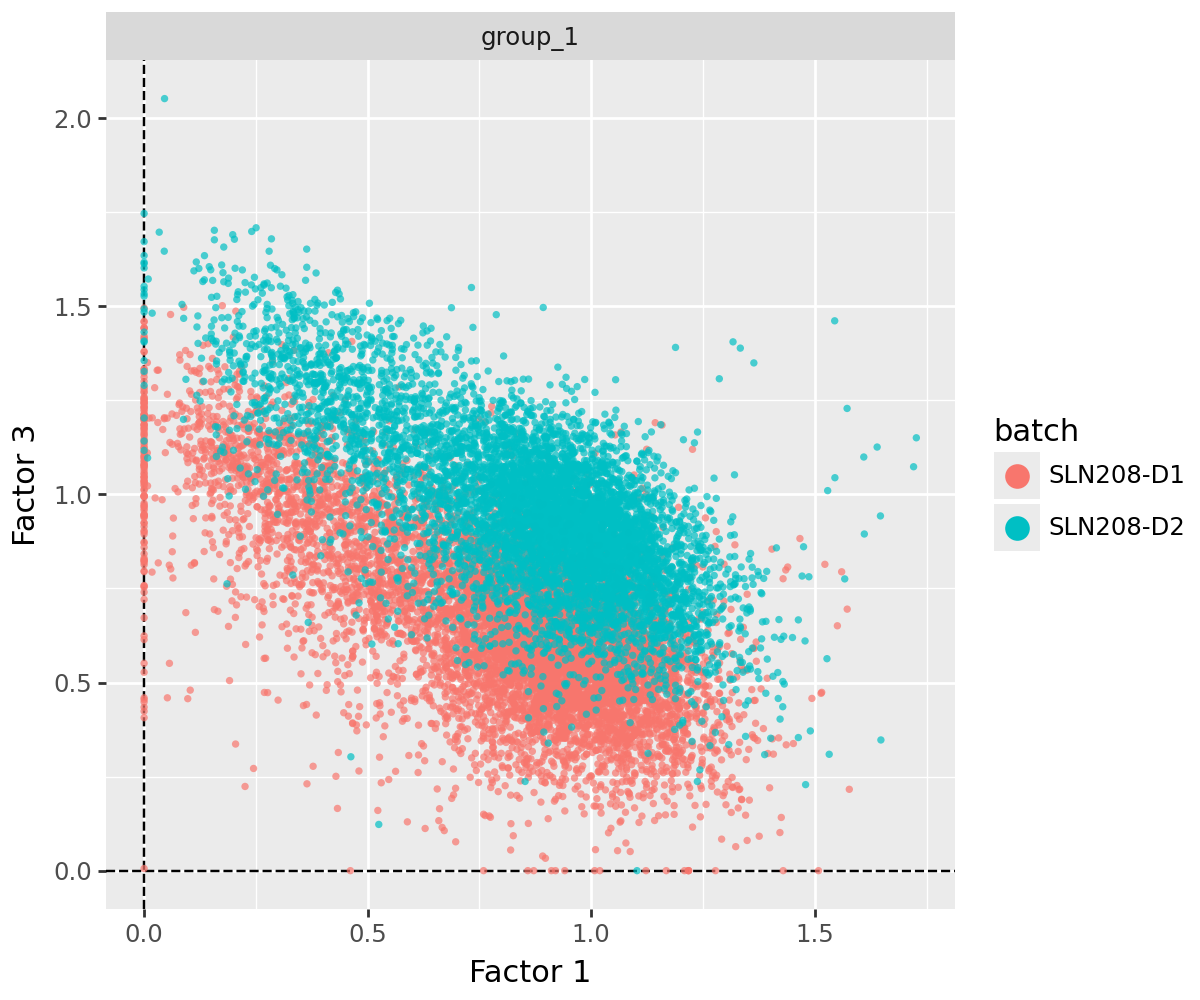

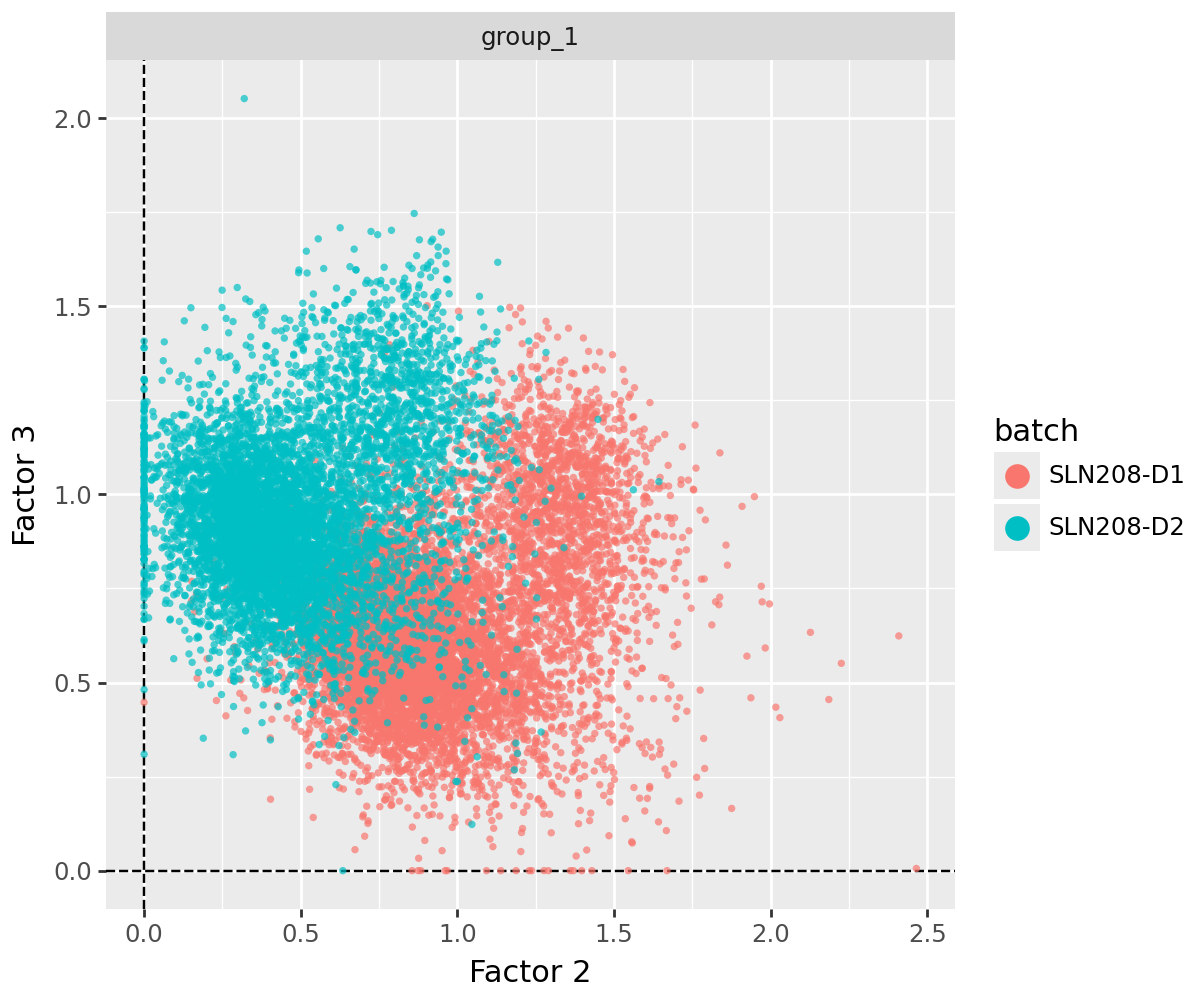

In [11]:
(
    mfl.pl.factors_scatter(
        model,
        "Factor 1",
        "Factor 2",
        color="batch",
        data=mdata,
        size=1.5,
        alpha=0.7,
        figsize=(6, 5),
    )
    + guides(color=guide_legend(override_aes={"size": 5, "alpha": 1}))
).show()
(
    mfl.pl.factors_scatter(
        model,
        "Factor 1",
        "Factor 3",
        color="batch",
        data=mdata,
        size=1.5,
        alpha=0.7,
        figsize=(6, 5),
    )
    + guides(color=guide_legend(override_aes={"size": 5, "alpha": 1}))
).show()
(
    mfl.pl.factors_scatter(
        model,
        "Factor 2",
        "Factor 3",
        color="batch",
        data=mdata,
        size=1.5,
        alpha=0.7,
        figsize=(6, 5),
    )
    + guides(color=guide_legend(override_aes={"size": 5, "alpha": 1}))
).show()

## Removing uninformed factors to mitigate batch effects

We remove the three uninformed dense factors (Factor 1–3) from the latent space and recompute the UMAP embedding.

By coloring cells by batch, we can directly assess how this adjustment affects clustering.
After removing these factors, batch separation is substantially reduced, indicating that MOFA-FLEX’s domain-informed factors primarily encode relevant biological signal, while uninformed components tend to absorb unwanted technical variation.

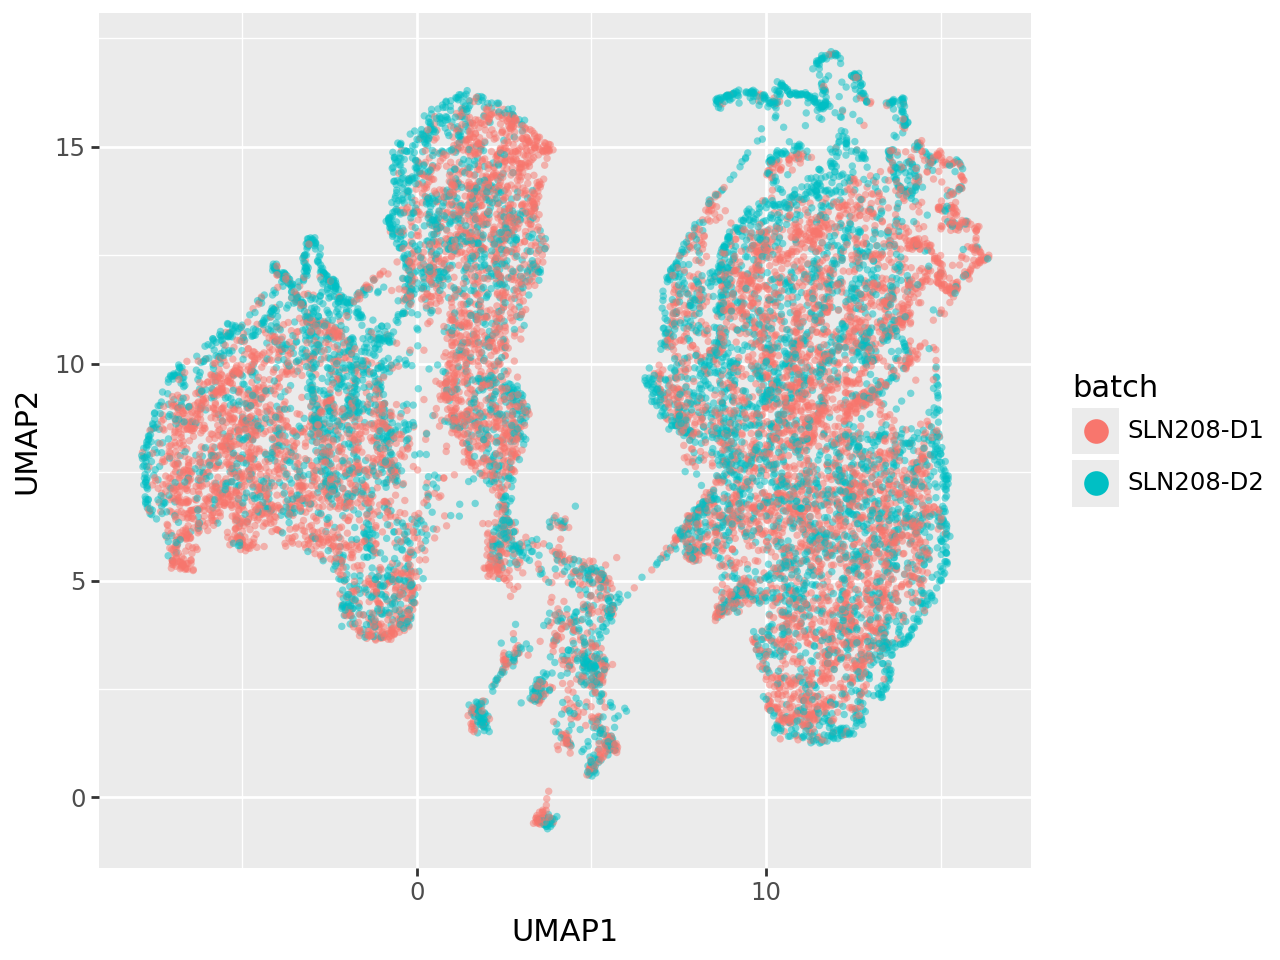

In [12]:
factor_adata = factor_adata[
    :, ~factor_adata.var_names.isin(["Factor 1", "Factor 2", "Factor 3"])
]
sc.pp.neighbors(factor_adata, use_rep="X")
sc.tl.umap(factor_adata, min_dist=0.4)

umap_data = pd.DataFrame(
    factor_adata.obsm["X_umap"],
    index=factor_adata.obs_names,
    columns=["UMAP1", "UMAP2"],
).assign(
    batch=factor_adata.obs["batch"], cell_type=factor_adata.obs["cell_types (high)"]
)
umap_data = umap_data.sample(frac=1, replace=False)

(
    ggplot(umap_data, aes(x="UMAP1", y="UMAP2", fill="batch"))
    + geom_point(stroke=0, alpha=0.5)
    + guides(fill=guide_legend(override_aes={"size": 5, "alpha": 1}))
)

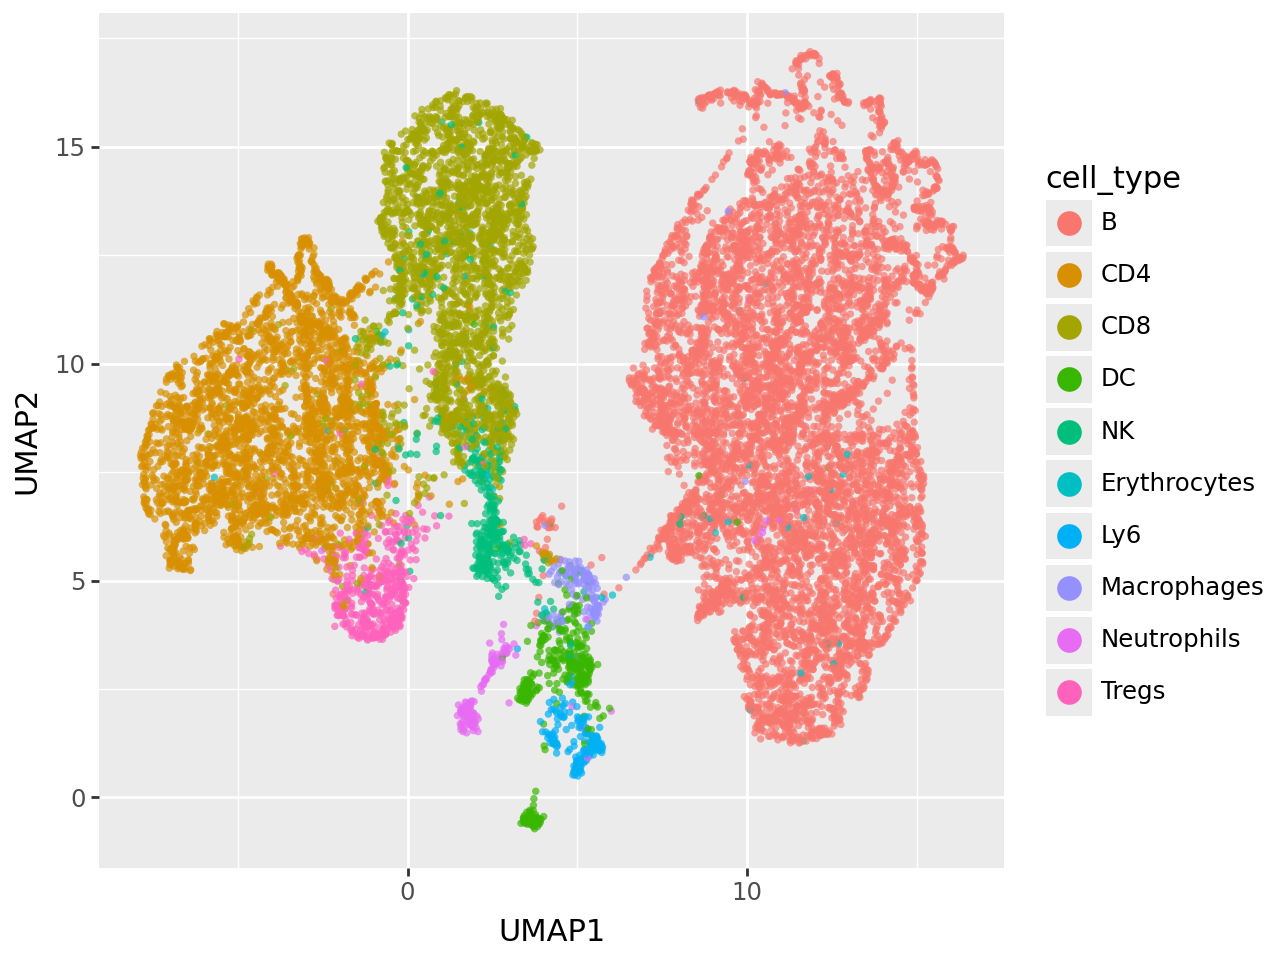

In [13]:
(
    ggplot(umap_data, aes(x="UMAP1", y="UMAP2", fill="cell_type"))
    + geom_point(stroke=0, alpha=0.7)
    + guides(fill=guide_legend(override_aes={"size": 5, "alpha": 1}))
)

## Ranking latent factors by cell type associations

To interpret the learned latent space, we can quantify which factors are most active in specific cell types.
This is analogous to marker gene ranking in Scanpy but applied to latent factors instead of genes.

The function below provides a minimal interface for this purpose. It:
- extracts the factor scores from the trained MOFA-FLEX model,
- uses `scanpy.tl.rank_genes_groups` to rank factors by their group-specific activity, and
- visualises the results as a dotplot (or heatmap, matrixplot, violin, etc.) for rapid interpretation.

This view highlights which factors capture distinct cell populations or experimental perturbations, providing an intuitive summary of how biological variation is structured in the latent space.

In [14]:
def rank(model, obs, groupby, group_idx, n_factors=3, pl_type="dotplot", **kwargs):
    """
    Rank latent factors by association with sample groups and visualise as a Scanpy plot.
    Useful for factor activity summaries (e.g. dotplots).

    Parameters
    ----------
    model : mfl.MOFAFLEX
        Trained MOFA-FLEX model.
    groupby : str
        Column in obs to group by (e.g. cell type or condition).
    group_idx : str
        Group key in model.get_factors("anndata") (e.g. "group_1").
    n_factors : int
        Number of top factors to plot per group.
    pl_type : str
        Type of Scanpy ranking plot: one of
        ["dotplot", "heatmap", "matrixplot", "violin", "stacked_violin"].
    **kwargs
        Additional arguments passed to Scanpy plotting function.
    """

    # Extract factors as AnnData
    factor_adata = ad.AnnData(model.get_factors()[group_idx])
    factor_adata.obs = obs

    # Compute ranking of factors across groups
    sc.tl.rank_genes_groups(factor_adata, groupby)

    # Select plotting function
    pl_type = (pl_type or "dotplot").lower()
    type_to_fn = {
        "dotplot": sc.pl.rank_genes_groups_dotplot,
        "heatmap": sc.pl.rank_genes_groups_heatmap,
        "matrixplot": sc.pl.rank_genes_groups_matrixplot,
        "violin": sc.pl.rank_genes_groups_violin,
        "stacked_violin": sc.pl.rank_genes_groups_stacked_violin,
    }
    if pl_type not in type_to_fn:
        raise ValueError(
            f"Invalid pl_type '{pl_type}'. Choose from {list(type_to_fn.keys())}."
        )

    # Run plotting function (show by default)
    return type_to_fn[pl_type](factor_adata, n_genes=n_factors, **kwargs)

/data/ilia/envs/famo/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 59 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.


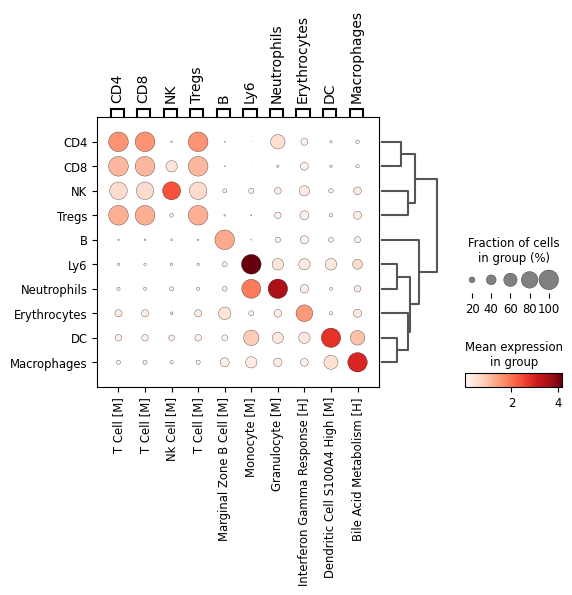

In [15]:
rank(
    model,
    mdata["rna"].obs,
    "cell_types (high)",
    group_idx="group_1",
    n_factors=1,
    pl_type="dotplot",
)

## Visualizing factor activity across cell types

After identifying the top cell type–associated factors, we next visualise their activity distributions across major immune cell classes.
Each boxplot represents the factor scores for one of the top-ranked programs, for example, those linked to marginal zone B cells, T cells, dendritic cells, or NK cells.

This view highlights the specificity and interpretability of the learned factors: Each factor is predominantly active in its corresponding cell population, while residual activity in other groups remains low, confirming clear biological separation.

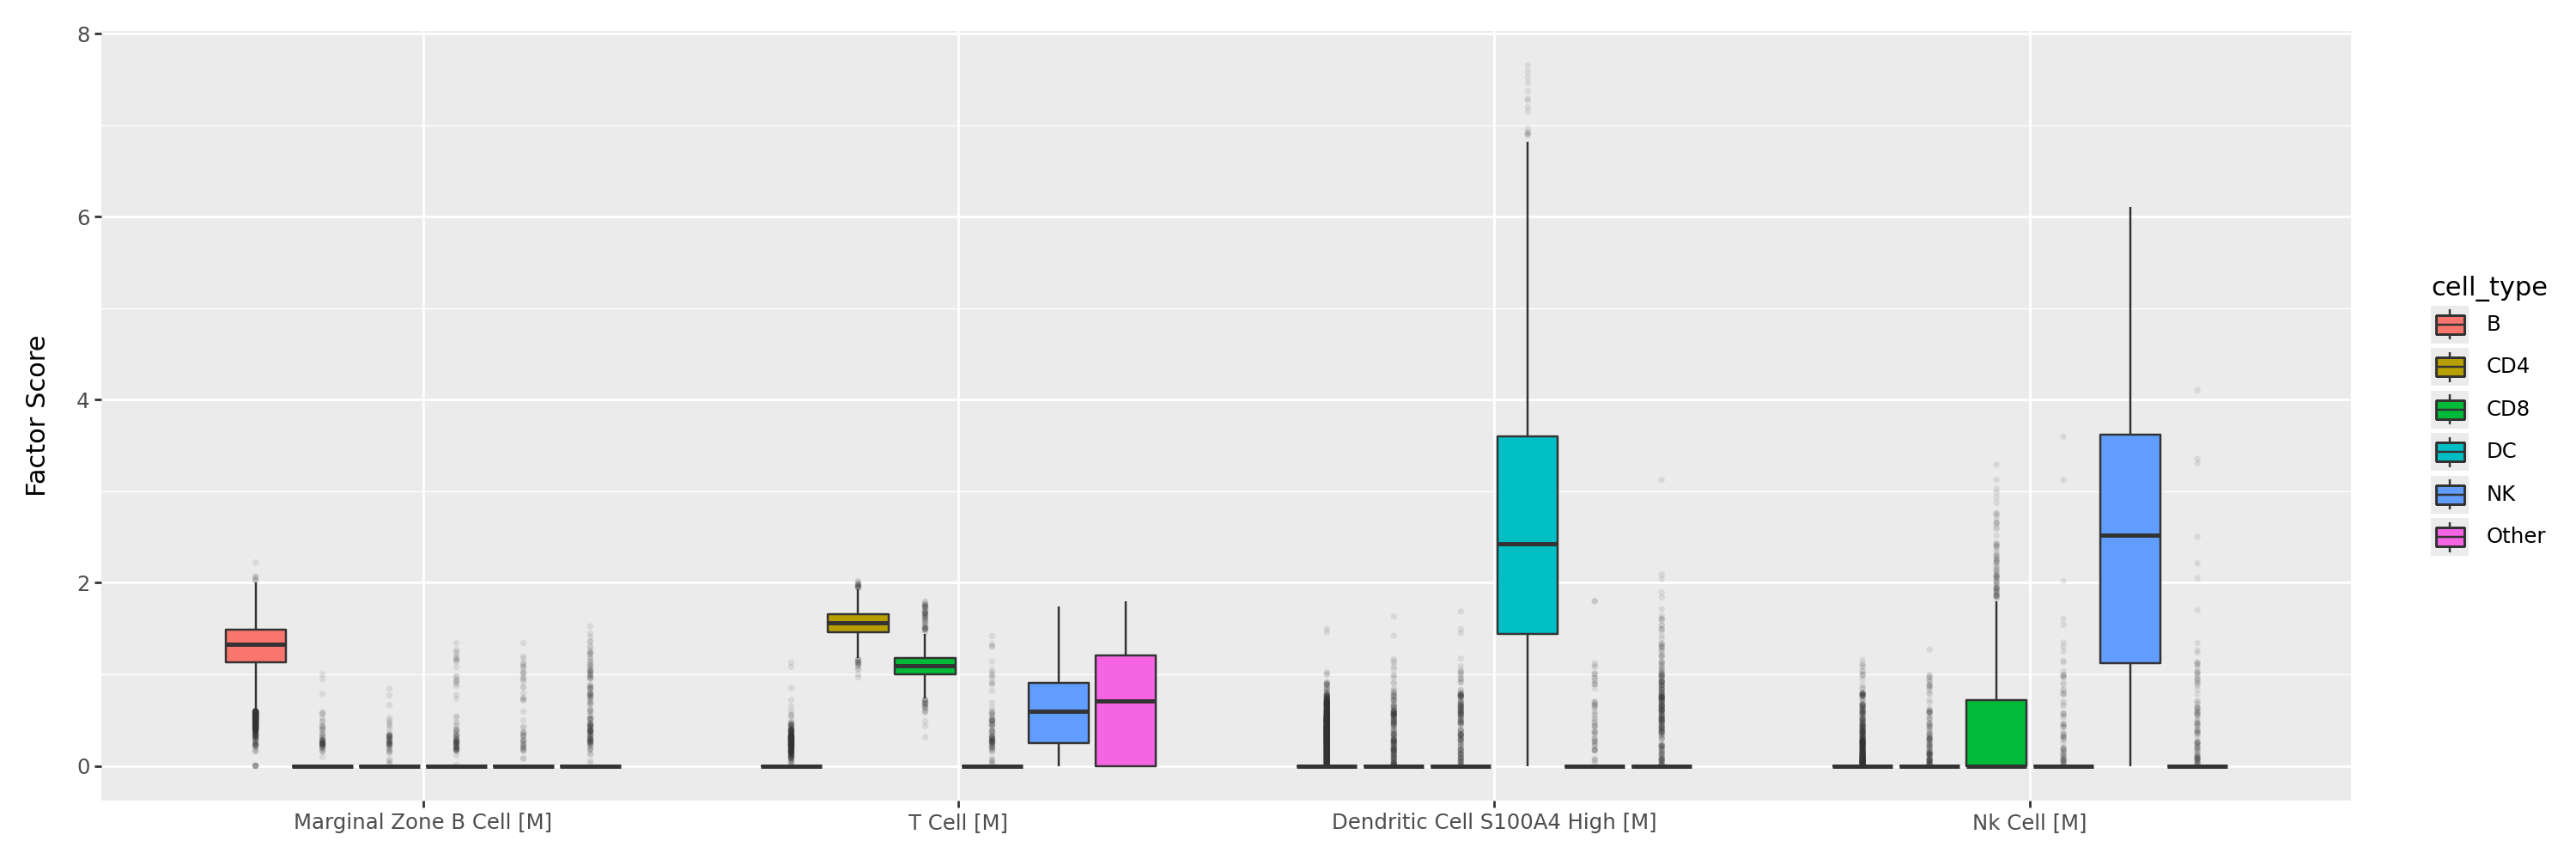

In [16]:
celltype_factors = [
    "Marginal Zone B Cell [M]",
    "T Cell [M]",
    "Dendritic Cell S100A4 High [M]",
    "Nk Cell [M]",
]
highlight_celltypes = ["B", "CD4", "CD8", "DC", "NK"]

df = (
    factor_adata.to_df()[celltype_factors]
    .assign(cell_type=factor_adata.obs["cell_types (high)"])
    .melt(id_vars=["cell_type"], var_name="Factor", value_name="Factor Score")
    .assign(
        cell_type=lambda x: pd.Categorical(
            np.where(x["cell_type"].isin(highlight_celltypes), x["cell_type"], "Other"),
            categories=highlight_celltypes + ["Other"],
        )
    )
)
df["Factor"] = pd.Categorical(df["Factor"], categories=celltype_factors)

(
    ggplot(df, aes(x="Factor", y="Factor Score", fill="cell_type"))
    + geom_boxplot(outlier_alpha=0.1, outlier_stroke=0)
    + theme(axis_text_x=element_text(rotation=0), figure_size=(15, 5))
    + labs(x="")
)

## Visualizing pairwise relationships between cell type–associated factors

To further examine how the top cell type–specific programs relate to one another, we visualize pairwise scatterplots of their factor activities.
Each point corresponds to a cell, colored by its annotated immune cell class.

These views reveal that: MOFA-FLEX–inferred factors are distinct yet biologically coherent, and the separation between programs aligns well with expected immune cell boundaries.

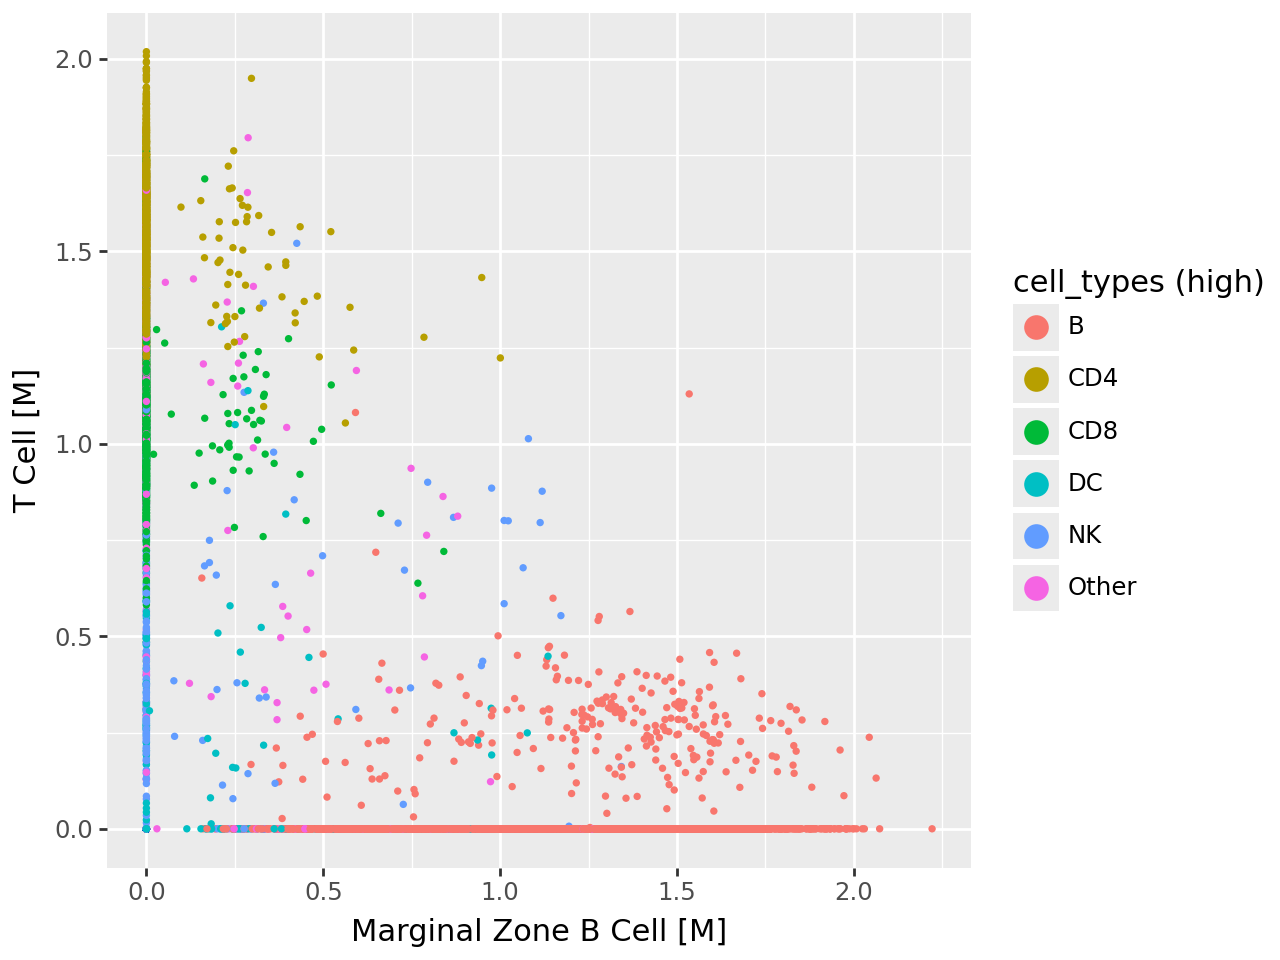

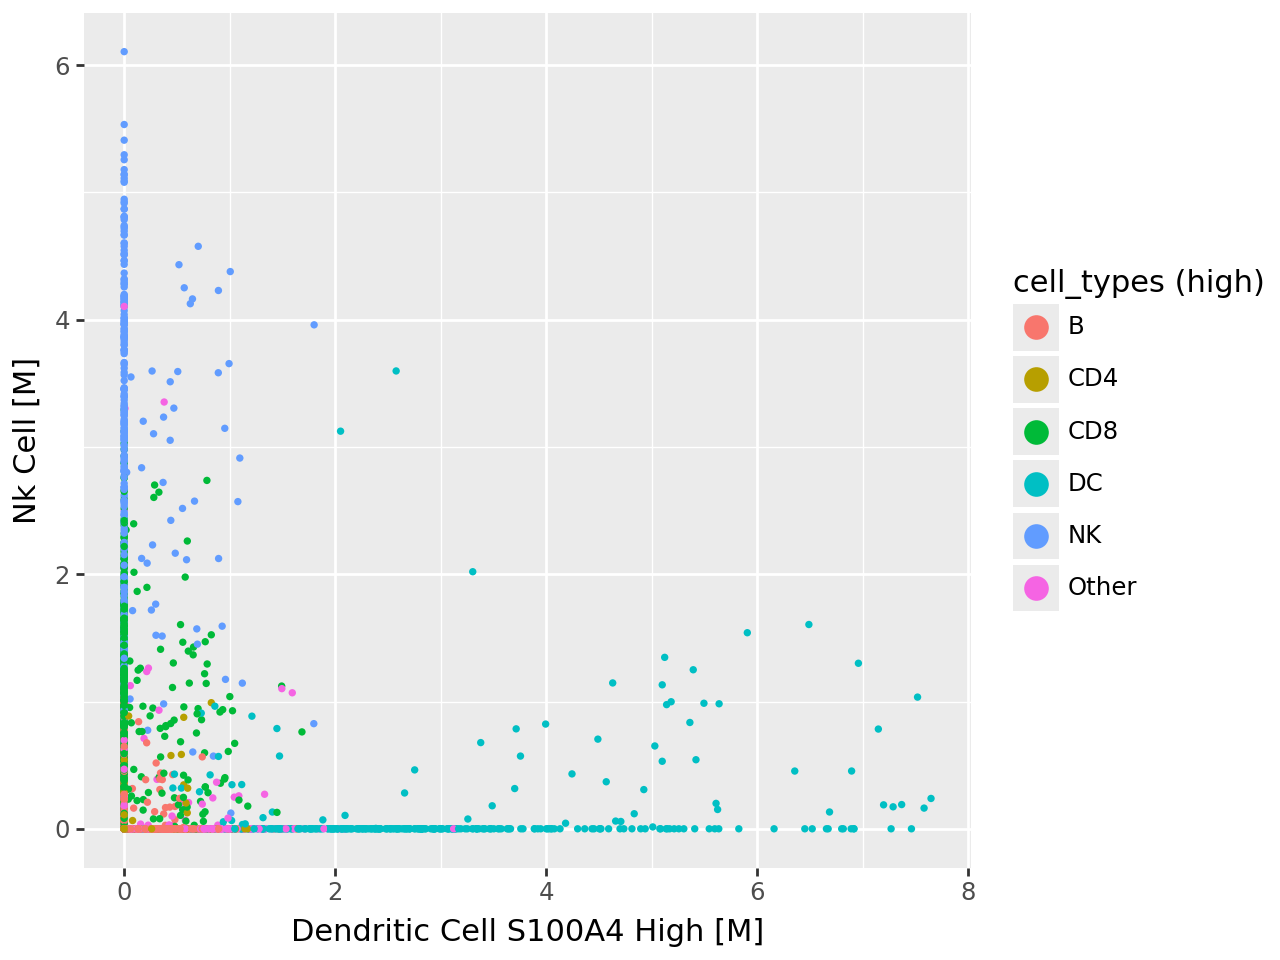

In [17]:
# Combine factors and metadata
celltype_df = factor_adata.to_df().join(factor_adata.obs)
celltype_df["cell_types (high)"] = celltype_df["cell_types (high)"].astype(str)
celltype_df.loc[
    ~celltype_df["cell_types (high)"].isin(["B", "CD4", "CD8", "DC", "NK"]),
    "cell_types (high)",
] = "Other"
celltype_df["cell_types (high)"] = pd.Categorical(
    celltype_df["cell_types (high)"],
    categories=["B", "CD4", "CD8", "DC", "NK", "Other"],
)

# --- Scatter 1: Marginal Zone B vs. T Cell factors ---
p1 = (
    ggplot(
        celltype_df,
        aes(x="Marginal Zone B Cell [M]", y="T Cell [M]", fill="cell_types (high)"),
    )
    + geom_point(stroke=0)
    + guides(fill=guide_legend(override_aes={"size": 5}))
)
p1.show()

# --- Scatter 2: Dendritic vs. NK Cell factors ---
p2 = (
    ggplot(
        celltype_df,
        aes(
            x="Dendritic Cell S100A4 High [M]",
            y="Nk Cell [M]",
            fill="cell_types (high)",
        ),
    )
    + geom_point(stroke=0)
    + guides(fill=guide_legend(override_aes={"size": 5}))
)
p2.show()

## Evaluating cell type specificity of MOFA-FLEX factors

To quantitatively assess how well each MOFA-FLEX–inferred factor captures a specific immune cell population, we compute receiver operating characteristic (ROC) curves and the corresponding area under the ROC (AUROC) scores.
For each major immune cell class (B, CD4 T, dendritic, and NK cells), we treat the factor activity as a continuous classifier score and evaluate its ability to distinguish the target cell type from all others.

These AUROC curves reveal that:
- each factor demonstrates high discriminative power (AUROC ≳ 0.9), confirming its biological specificity
- the separation is particularly strong for Marginal Zone B, T, Dendritic, and NK cell programs, aligning well with the cell-type annotated clusters observed in the UMAP and boxplot analyses

Together, these results highlight that MOFA-FLEX not only yields interpretable latent factors, but also produces quantitatively robust predictors of cell identity.

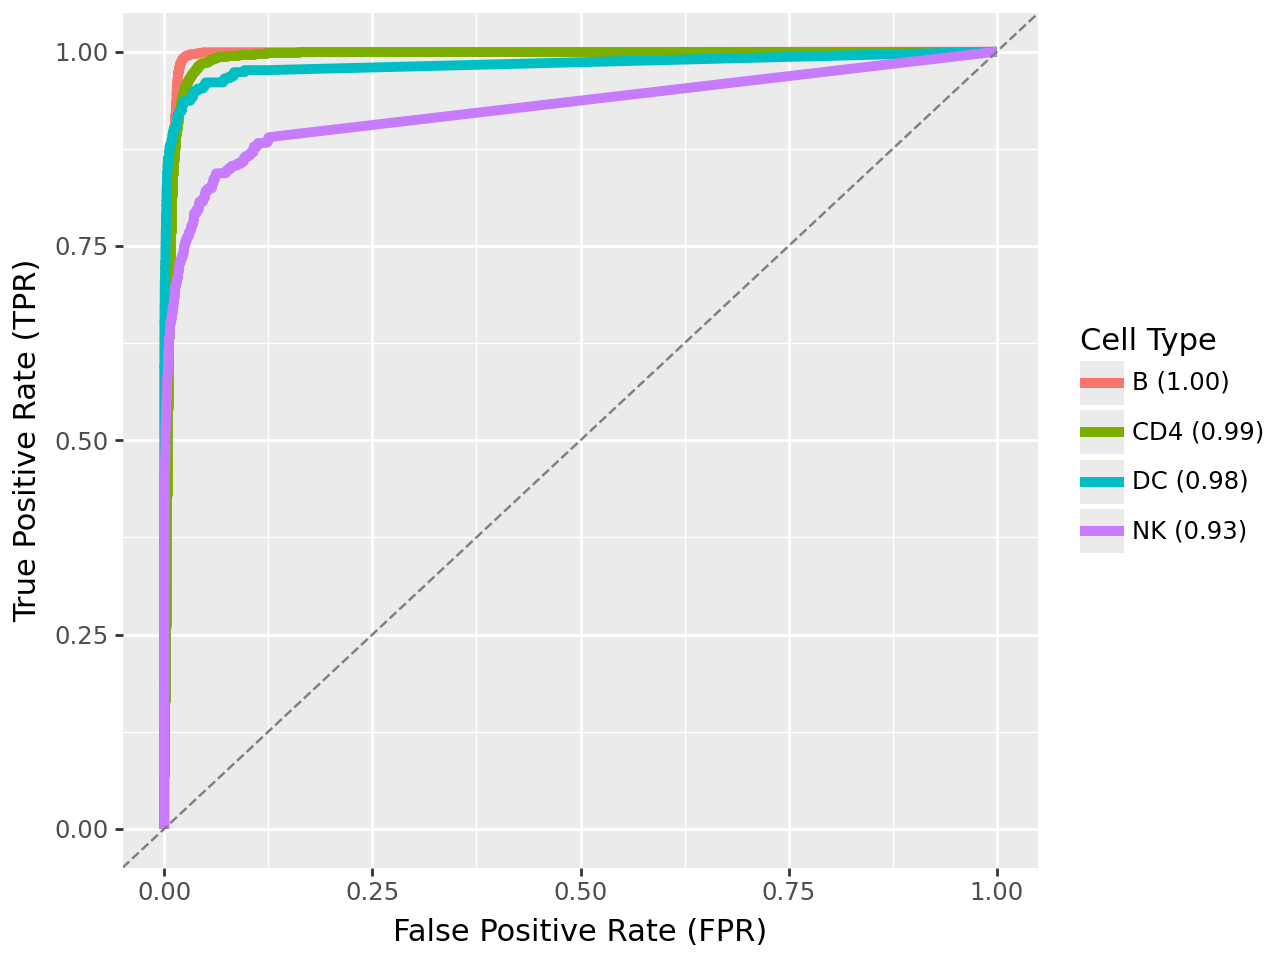

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve

# Define mapping from cell type to corresponding factor
celltype_to_factor = {
    "B": "Marginal Zone B Cell [M]",
    "CD4": "T Cell [M]",
    "DC": "Dendritic Cell S100A4 High [M]",
    "NK": "Nk Cell [M]",
}

# Compute ROC and AUROC for each selected cell type-factor pair
dfs = []
for ct, ctf in celltype_to_factor.items():
    # Binary label: 1 for this cell type, 0 for all others
    y_true = factor_adata.obs["cell_types (high)"] == ct
    y_score = factor_adata.to_df()[ctf]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc_score = roc_auc_score(y_true, y_score)

    label = f"{ct} ({auroc_score:.2f})"
    dfs.append(pd.DataFrame({"FPR": fpr, "TPR": tpr, "Cell Type": label}))

# Combine all ROC data
auroc_df = pd.concat(dfs, axis=0)

# Plot AUROC curves
p = (
    ggplot(auroc_df, aes(x="FPR", y="TPR", color="Cell Type"))
    + geom_line(size=2)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="gray")
    + labs(x="False Positive Rate (FPR)", y="True Positive Rate (TPR)")
)
p.show()

## Inspecting top weighted features in the RNA and protein modalities

To interpret the biological drivers of each factor, we visualize the top-weighted features for both the transcriptomic (RNA) and protein (CITE-seq) modalities.
Each bar corresponds to the feature loading within the respective modality, highlighting the genes or proteins most strongly contributing to the factor's definition.

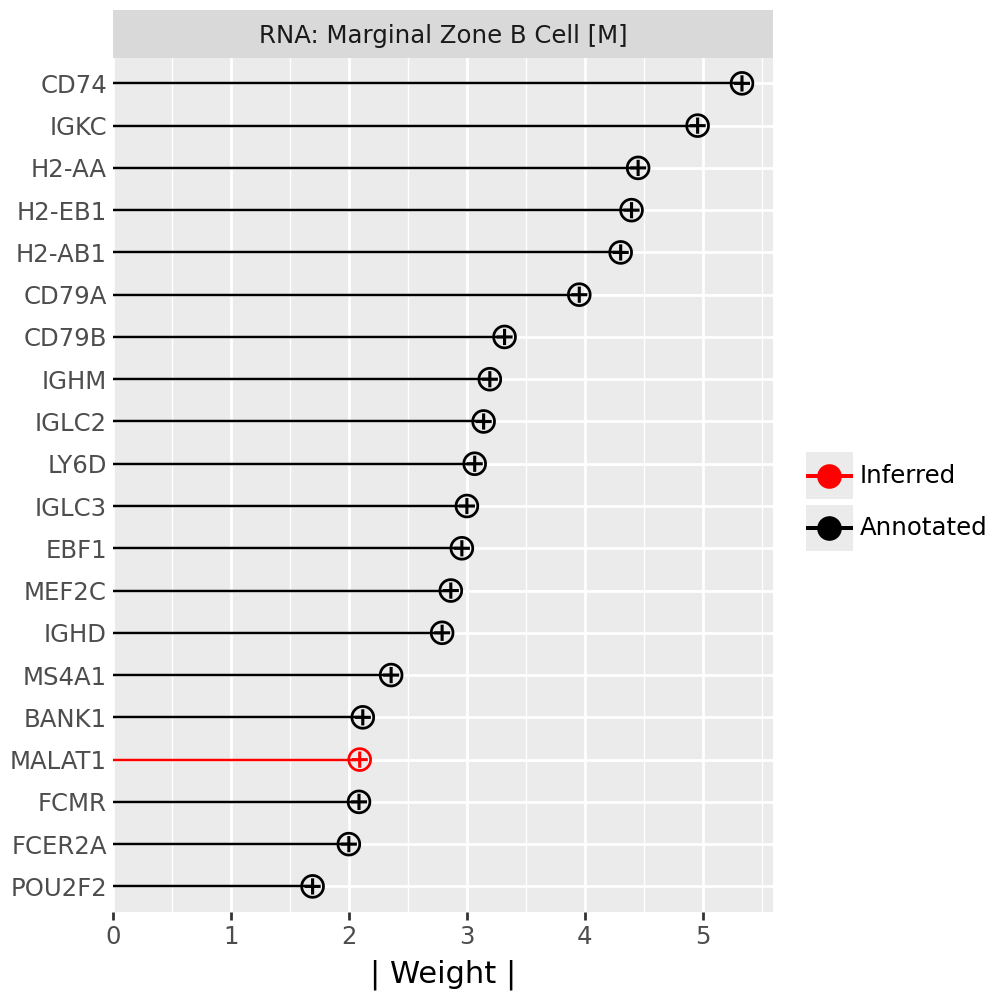

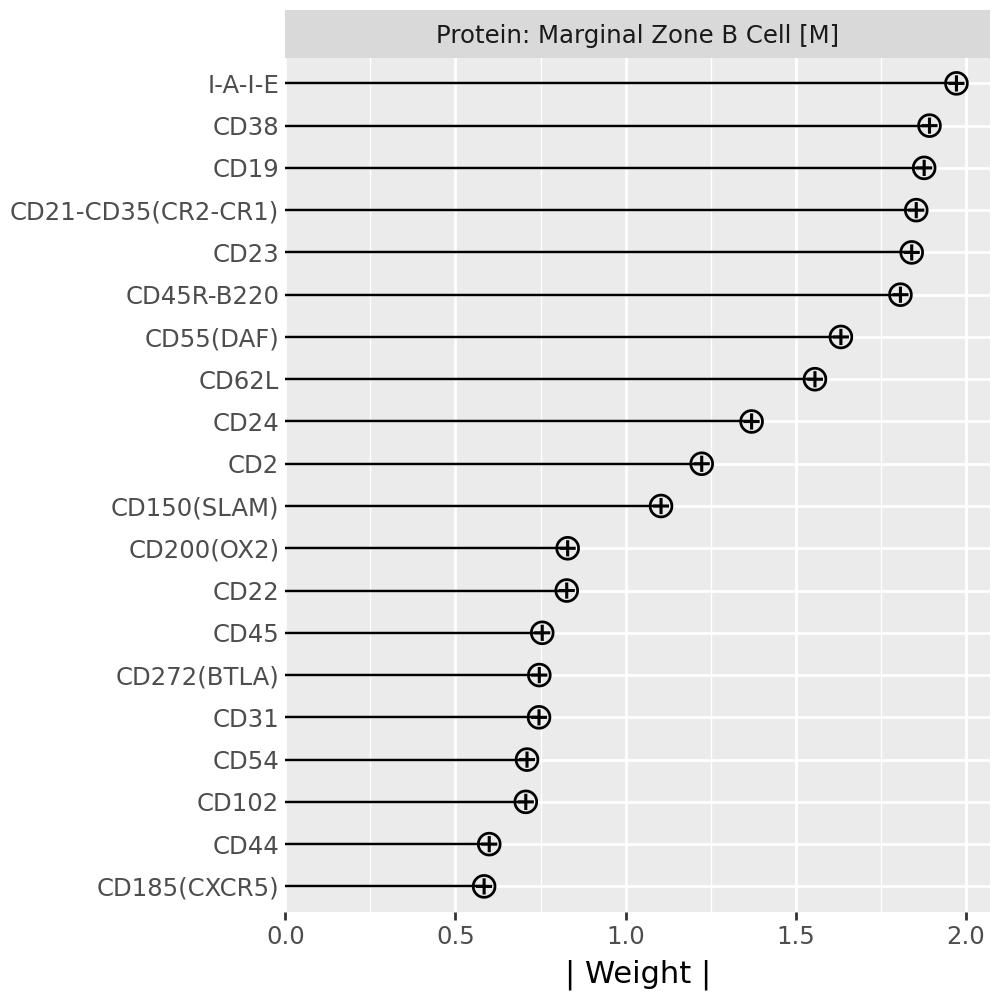

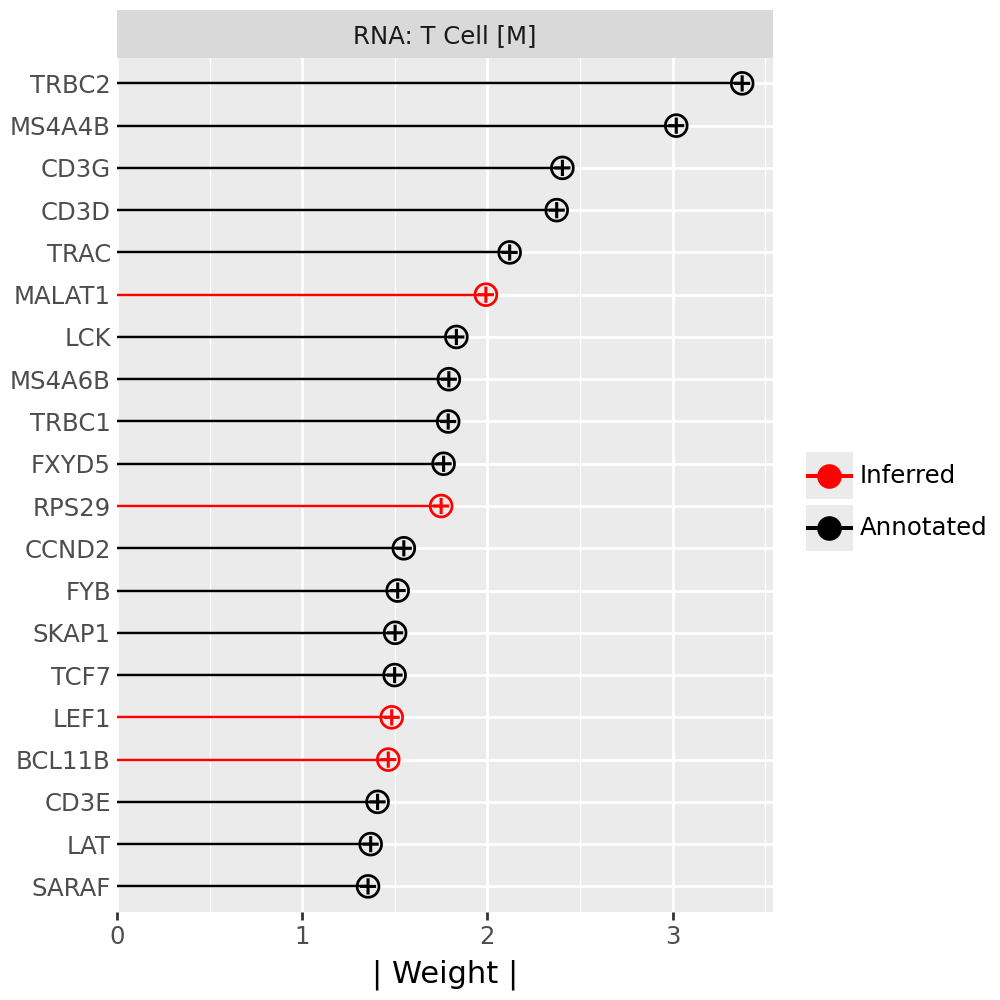

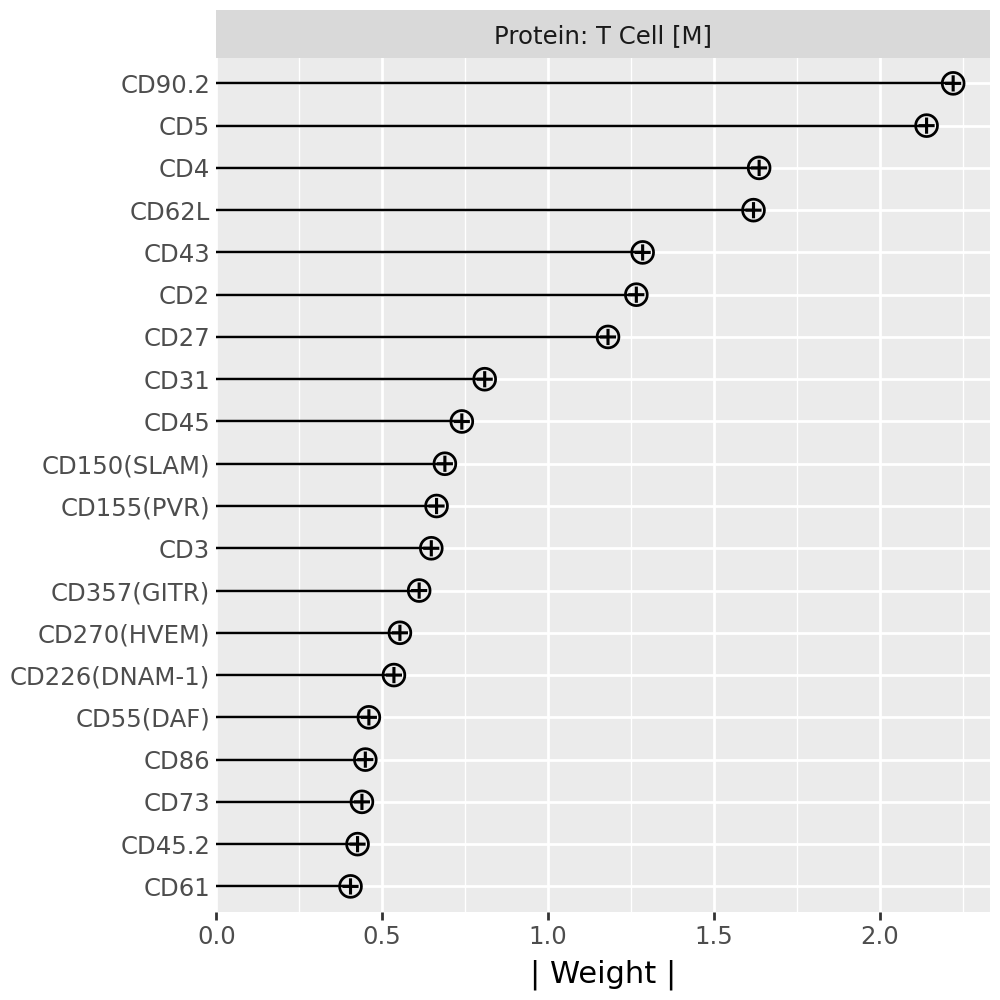

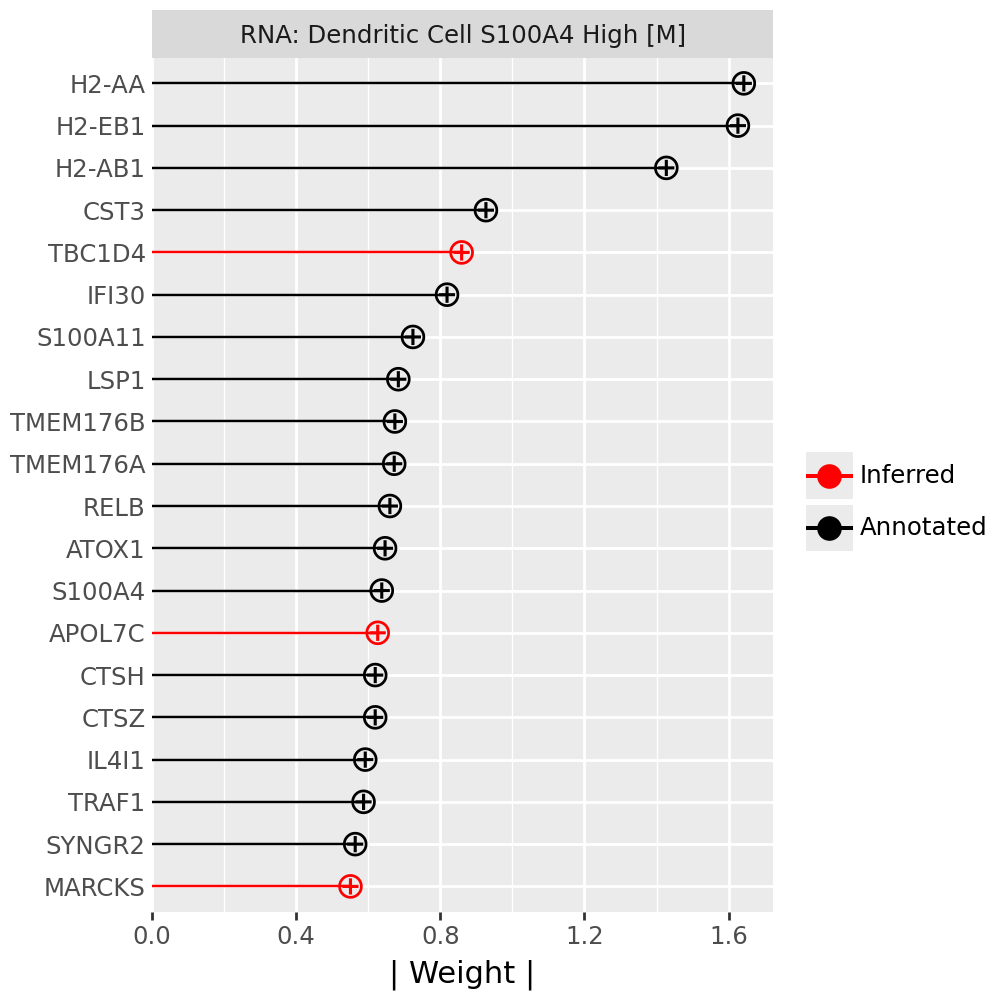

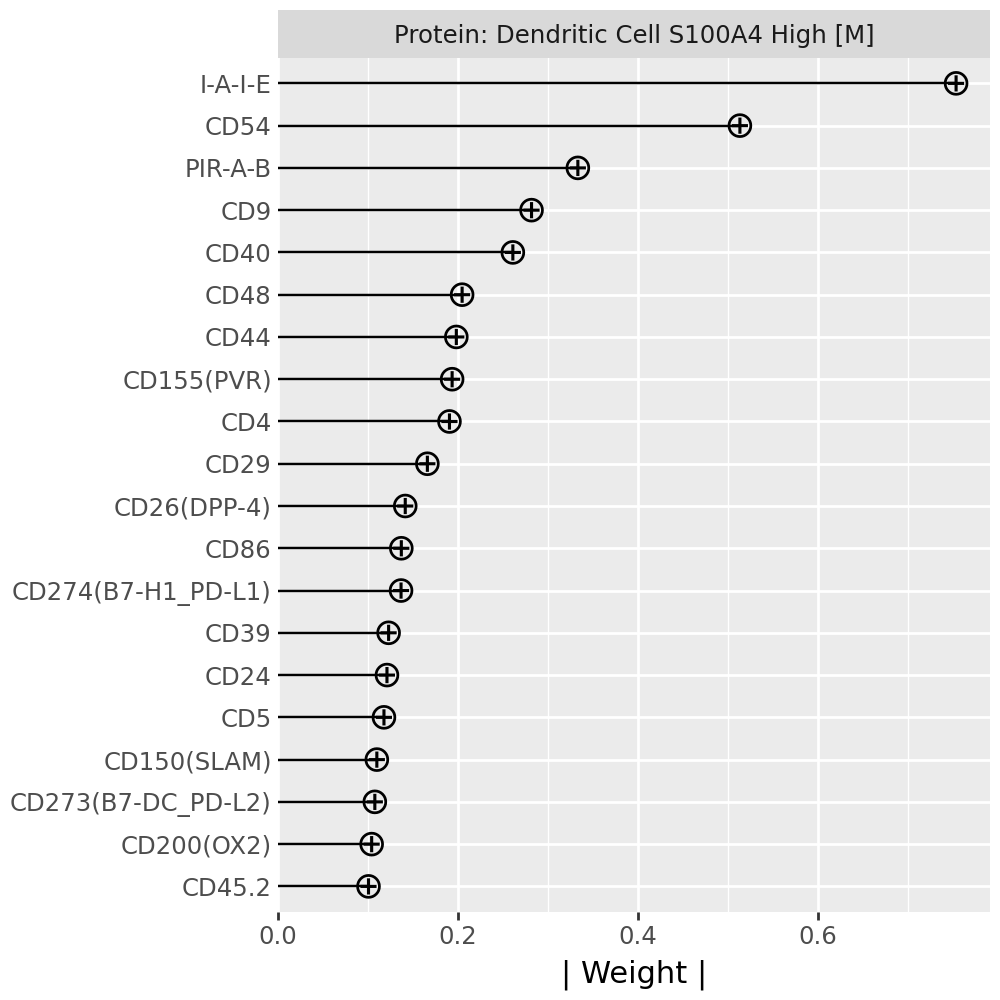

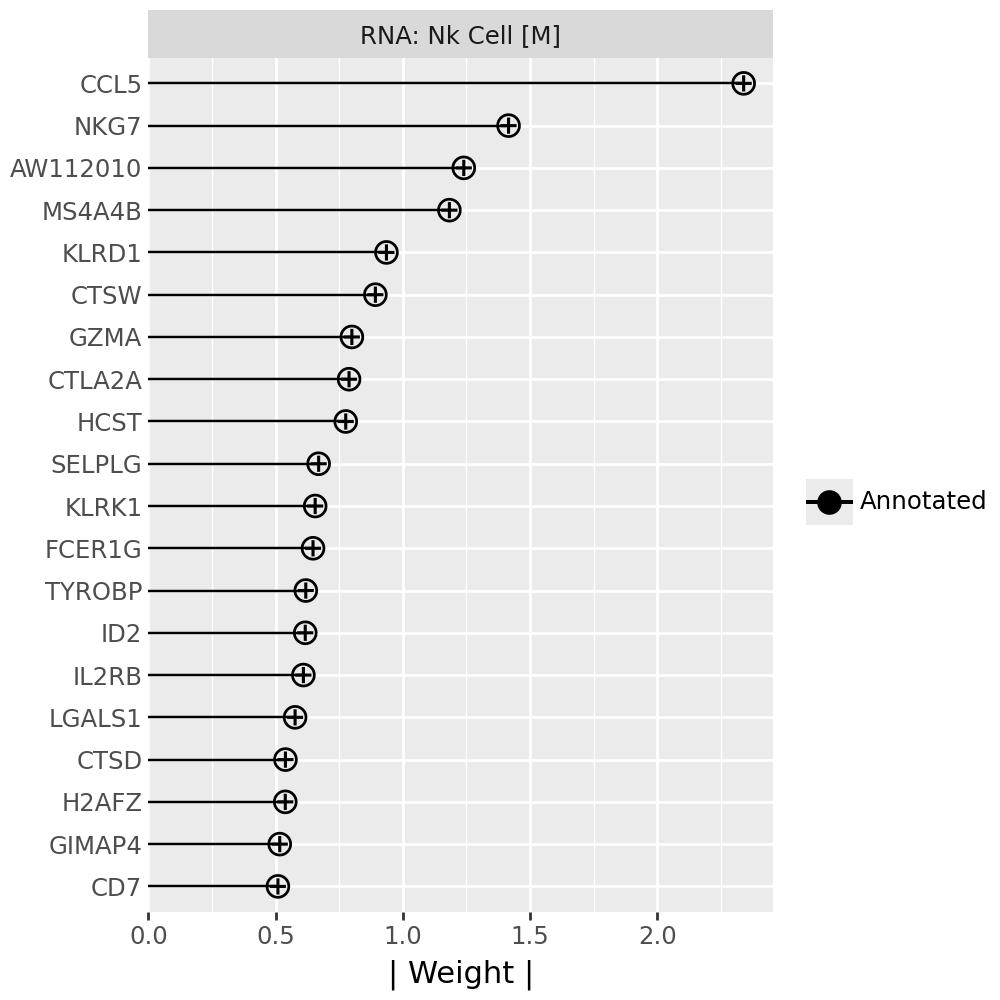

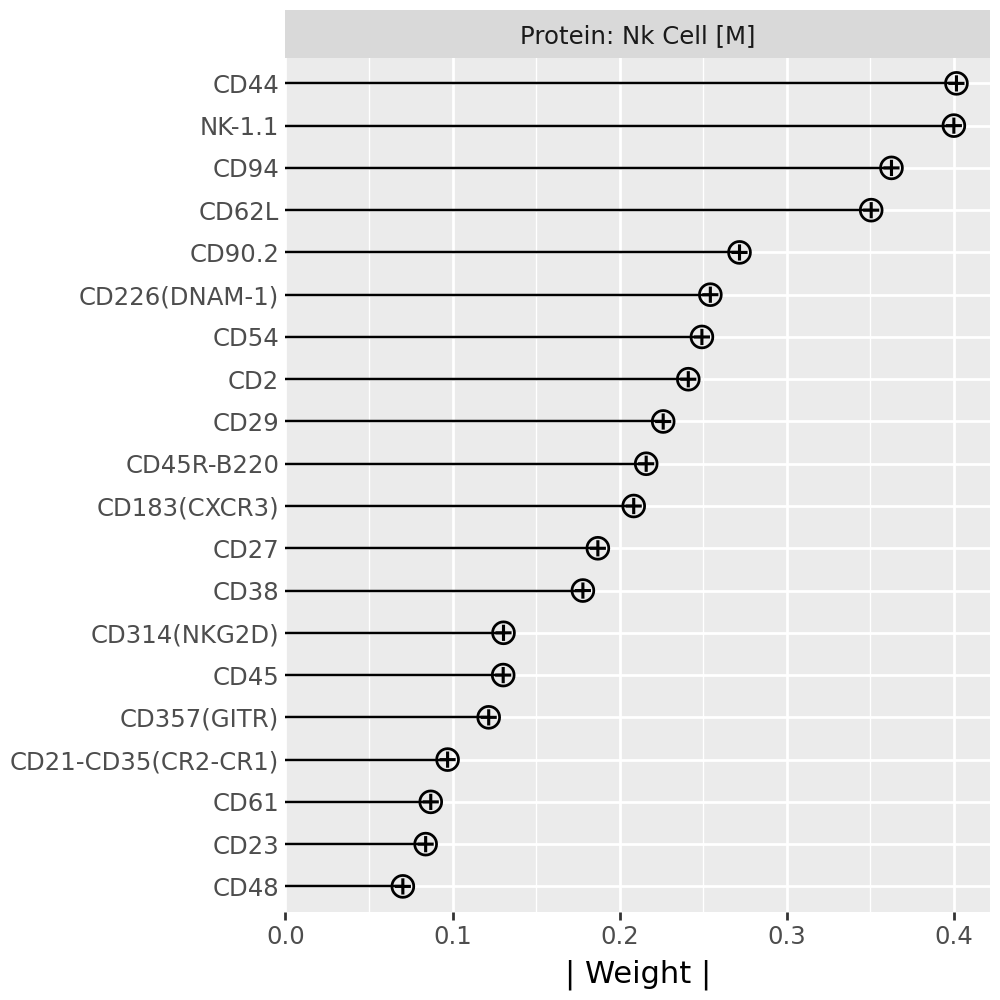

In [19]:
for rf in celltype_factors:
    for view in ["rna", "prot"]:
        width = 4

        p = mfl.pl.top_weights(model, n_features=20, views=view, factors=rf)

        # Clean up protein labels (remove prefixes/suffixes)
        if view == "prot":
            p = p + scale_y_discrete(labels=lambda labels: [s[4:-6] for s in labels])

        # Add a clear facet title for each view
        p = p + facet_wrap(
            "factor",
            labeller=lambda _: {"rna": "RNA", "prot": "Protein"}[view] + f": {rf}",  # noqa: B023
        )
        p.show()